In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(sys.executable)

/home/kethe/AI_projects/higgs_ml/.venv/bin/python


In [85]:
df = pd.read_csv("../data/idm_pt.tsv", sep="\t")
print(df.shape)
df.head()

(97588, 18)


,index,trantype,transition,transition_number,transition_pattern,mH,mA,mHp,l2,l345,Tcrit,Tnuc,high_vev_at_Tnuc,low_vev_at_Tnuc,Delta_p_at_Tnuc,Delta_rho_at_Tnuc,alpha,beta/H
0,1,1,o -1-> h,1.0,oh1,247.358088,421.539065,445.449733,1.557838,1.090046,101.395212,97.621578,[-1.42111732e-06 -2.10889353e-07],[1.41693714e+02 1.13924838e-06],5.423588e+06,1.507808e+08,0.014675,5871.365610
1,3,2,o -2-> h,1.0,oh2,156.575941,192.276210,180.903670,1.302137,0.320535,-999.000000,-999.000000,-999,-999,-9.990000e+02,-9.990000e+02,-999.000000,-999.000000
2,4,1,o -1-> h,1.0,oh1,155.047213,308.667919,330.435889,0.848921,0.659560,119.477012,118.482277,[ 1.89514806e-05 -1.79557620e-07],[1.08048506e+02 7.18751645e-07],1.025623e+06,1.309051e+08,0.005424,27406.102736
3,5,1,s -1-> h,2.0,os2-sh1,184.326946,215.404108,191.331668,3.634031,2.093274,121.328095,112.445864,[-5.48186455e-05 7.60137689e+01],[1.06913657e+02 2.73299324e-04],9.377717e+06,1.400244e+08,0.008391,2527.352502
4,9,2,o -2-> h,1.0,oh2,122.486365,145.162724,168.769167,3.699726,0.283079,-999.000000,-999.000000,-999,-999,-9.990000e+02,-9.990000e+02,-999.000000,-999.000000


In [86]:
df["trantype"].value_counts()

trantype
1    60227
2    37361
Name: count, dtype: int64

In [87]:
df["transition_number"].value_counts()

transition_number
1.0    83713
2.0     9532
3.0     4329
4.0       14
Name: count, dtype: int64

In [20]:
df["transition_pattern"].value_counts() 

transition_pattern
oh1                50313
oh2                33400
os1-sh1             4830
os2-sh1             4485
os2-sh_s2-h_sh2     3786
os2-sh_s1-h_sh2      202
os2-sh2              132
os1-sh_s1-h_sh2      101
os1-sh_s2-h_sh2       80
os2-ss1-sh1           57
os2-sh_s2-h_sh1       47
oh_s1-h_sh2           39
os1-sh2               29
os2-sh2-hh_s1         28
os2-so1-oh1           20
os2-so1-os2-sh1       14
oh_s2-h_sh2            6
oh1-hs1                5
oh2-hh1                4
oh2-hs1-ss1            2
oh2-hs1                2
os2-sh_s1-h_sh1        2
os1-ss1-sh1            1
oh2-hs1-sh1            1
os2-ss2-sh1            1
oh1-hh_s2-h_sh2        1
Name: count, dtype: int64

In [88]:
pd.crosstab(df["transition_number"], df["trantype"])

trantype,1,2
transition_number,,
1.0,50313,33400
2.0,9388,144
3.0,512,3817
4.0,14,0


In [89]:
df.groupby("index").size().value_counts()

1    91000
2     1401
3     1262
Name: count, dtype: int64

In [90]:
bsm_columns = ["mH", "mA", "mHp", "l2", "l345"]

duplicates = df.duplicated(subset=["index"] + bsm_columns, keep=False)

df.loc[duplicates, ["index"] + bsm_columns + 
       ["transition", "transition_number", "transition_pattern"]].sort_values("index").head(30)

,index,mH,mA,mHp,l2,l345,transition,transition_number,transition_pattern
43,71,79.220772,187.988742,181.511539,3.584758,1.105940,o -2-> s,3.0,os2-sh_s2-h_sh2
44,71,79.220772,187.988742,181.511539,3.584758,1.105940,h_s -2-> h,3.0,os2-sh_s2-h_sh2
45,71,79.220772,187.988742,181.511539,3.584758,1.105940,s -2-> h_s,3.0,os2-sh_s2-h_sh2
53,91,63.304746,156.472663,213.420274,3.659372,1.310399,s -2-> h_s,3.0,os2-sh_s2-h_sh2
54,91,63.304746,156.472663,213.420274,3.659372,1.310399,o -2-> s,3.0,os2-sh_s2-h_sh2
55,91,63.304746,156.472663,213.420274,3.659372,1.310399,h_s -2-> h,3.0,os2-sh_s2-h_sh2
68,110,81.866509,154.011469,82.856642,3.902057,1.009203,h_s -2-> h,3.0,os2-sh_s2-h_sh2
69,110,81.866509,154.011469,82.856642,3.902057,1.009203,s -2-> h_s,3.0,os2-sh_s2-h_sh2
70,110,81.866509,154.011469,82.856642,3.902057,1.009203,o -2-> s,3.0,os2-sh_s2-h_sh2
130,198,67.205096,114.751223,156.969682,2.920659,1.190135,s -2-> h_s,3.0,os2-sh_s2-h_sh2


In [ ]:
df_clean = df.copy()

# Successful PTs for which Trit couldn't be found means that Tcrit is very close to Tnuc.
# We thus replace the missing Tcrit value by the corresponding Tnuc.
df_clean["Tcrit"] = df_clean["Tcrit"].mask(df_clean["Tcrit"] == -999, df_clean["Tnuc"])

# Remove points where the computation of beta/H was unsuccessful.
df_clean = df_clean[df_clean["beta/H"] != -999]
df_clean = df_clean.replace(-999, np.nan)

df_clean.isna().sum()

index                 0
trantype              0
transition            0
transition_number     0
transition_pattern    0
mH                    0
mA                    0
mHp                   0
l2                    0
l345                  0
Tcrit                 0
Tnuc                  0
high_vev_at_Tnuc      0
low_vev_at_Tnuc       0
Delta_p_at_Tnuc       0
Delta_rho_at_Tnuc     0
alpha                 0
beta/H                0
dtype: int64

In [117]:
df_clean["log_alpha"] = np.log10(df_clean["alpha"])
df_clean["log_beta/H"] = np.log10(df_clean["beta/H"])
one_step_fopt = df_clean[df_clean["transition_pattern"] == 'oh1'].copy()


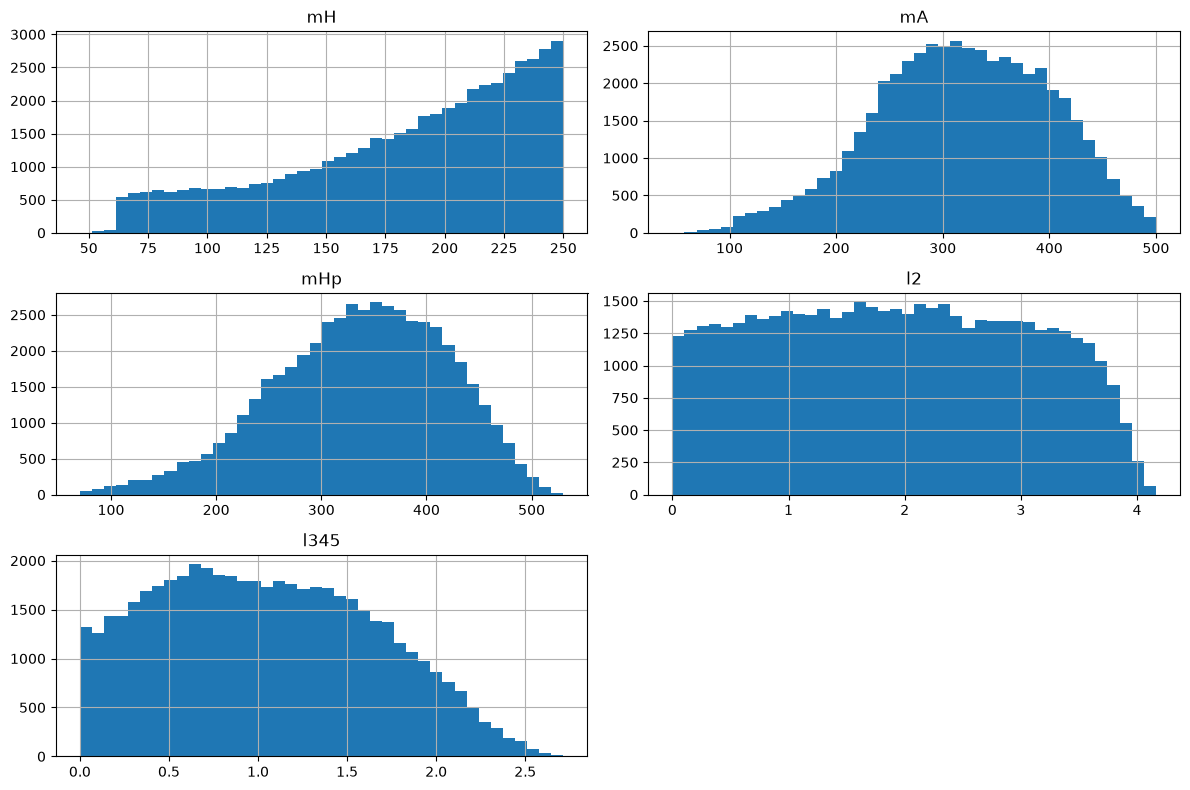

In [118]:
bsm_features = ["mH", "mA", "mHp", "l2", "l345"]
one_step_fopt[bsm_features].hist(bins=40, figsize=(12, 8))

plt.tight_layout()
plt.show()

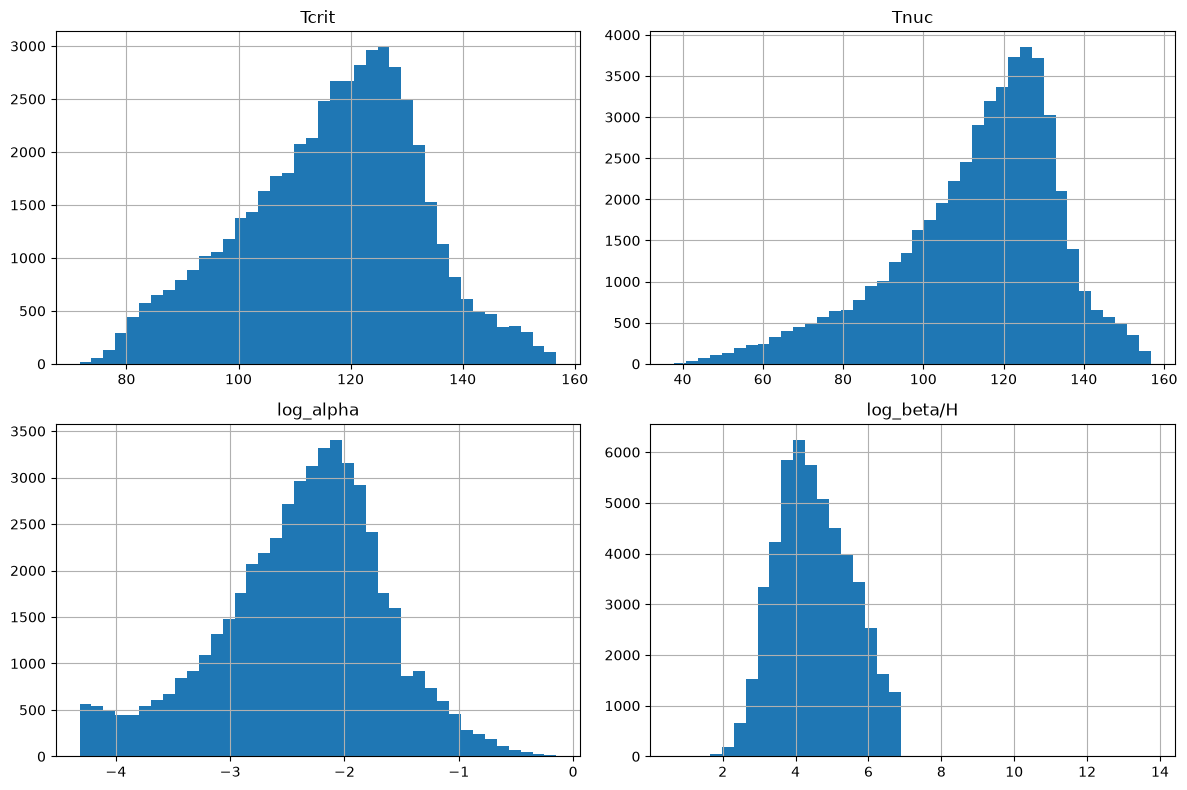

In [119]:
pt_targets = ["Tcrit", "Tnuc", "log_alpha", "log_beta/H"]

one_step_fopt[pt_targets].hist(bins=40, figsize=(12, 8))

plt.tight_layout()
plt.show()

In [120]:
one_step_fopt[pt_targets].describe().T

,count,mean,std,min,25%,50%,75%,max
Tcrit,50297.0,116.654636,15.814025,71.638750,106.102871,118.417725,127.767578,156.720831
Tnuc,50297.0,113.359869,20.384383,37.885160,102.171051,117.314253,127.552613,156.713495
log_alpha,50297.0,-2.379646,0.730958,-4.317576,-2.814510,-2.296829,-1.894980,-0.146363
log_beta/H,50297.0,4.515161,1.016236,0.666147,3.765377,4.432380,5.266219,13.749588


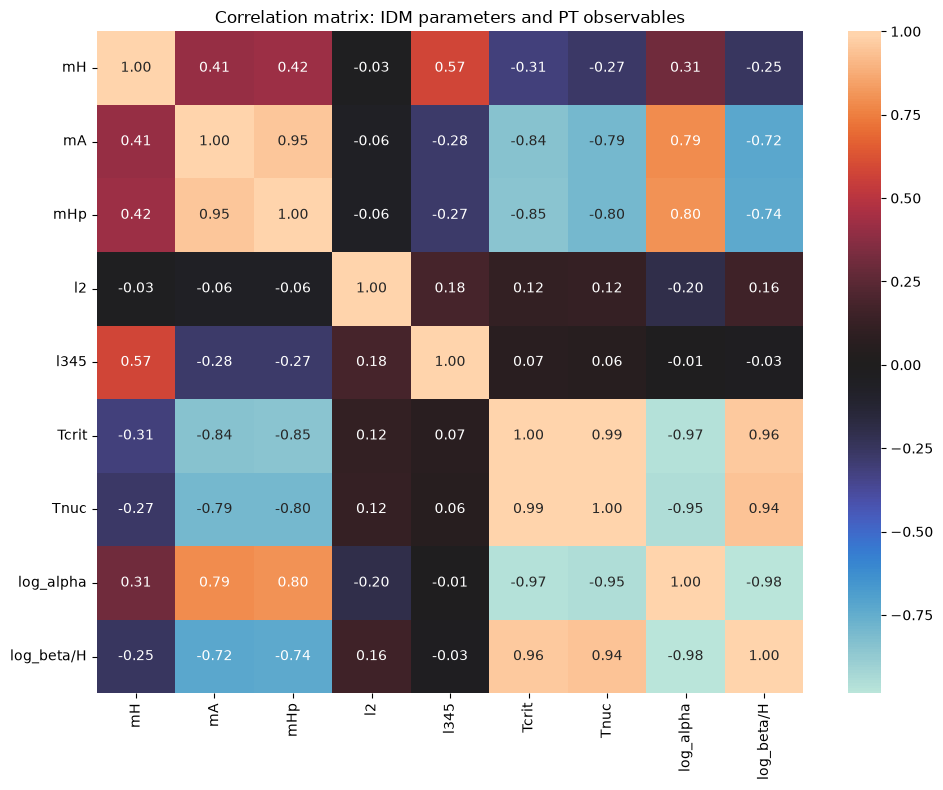

In [ ]:
corr_columns = bsm_features + pt_targets

correlation = (one_step_fopt[corr_columns].corr())

plt.figure(figsize=(10, 8))

sns.heatmap(correlation, annot=True, fmt=".2f", center=0)

plt.title("Correlation matrix: IDM parameters and PT observables")

plt.tight_layout()
plt.show()